In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
dataset_url = 'https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv' #url des datas
project_dir = '/content/drive/MyDrive/Documents/GIA3/IAA' #dossier du projet
data_dir = os.path.join(project_dir, 'data') #data
file_dir = os.path.join(data_dir, 'weatherAUS.csv') #fichier

df_weather_brut = pd.read_csv(file_dir) #dataset brut
df_weather_brut

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


#SECTION 1 : ANALYSE EXPLORATOIRE

In [3]:
#exploration du dataset
df_weather_brut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## DESCRIPTION

"Sunshine", "WindGustDir", "WindGustSpeed", "RainToday", "RainTomorrow"

In [4]:
df1 = df_weather_brut[["Rainfall", "Sunshine", "Evaporation", "WindGustDir", "WindGustSpeed", "WindDir9am", "WindDir3pm", "WindSpeed9am", "WindSpeed3pm"]]
df2 = df_weather_brut[["Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm", "RainToday", "RainTomorrow"]]
df1
df1.describe()

,Rainfall,Sunshine,Evaporation,WindGustSpeed,WindSpeed9am,WindSpeed3pm
count,142199.000000,75625.000000,82670.000000,135197.000000,143693.000000,142398.000000
mean,2.360918,7.611178,5.468232,40.035230,14.043426,18.662657
std,8.478060,3.785483,4.193704,13.607062,8.915375,8.809800
min,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000
25%,0.000000,4.800000,2.600000,31.000000,7.000000,13.000000
50%,0.000000,8.400000,4.800000,39.000000,13.000000,19.000000
75%,0.800000,10.600000,7.400000,48.000000,19.000000,24.000000
max,371.000000,14.500000,145.000000,135.000000,130.000000,87.000000


In [5]:
df2
df2.describe()

,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


## ANALYSE DES VALEURS NULLES

In [6]:
#les valeurs nulles
df_weather_brut.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [7]:
# les valeurs nulles en %
print("Valeurs nulles en %")
df_weather_brut.isnull().mean()*100


Valeurs nulles en %


,0
Date,0.000000
Location,0.000000
MinTemp,1.020899
MaxTemp,0.866905
Rainfall,2.241853
Evaporation,43.166506
Sunshine,48.009762
WindGustDir,7.098859
WindGustSpeed,7.055548
WindDir9am,7.263853


visualiser les valeurs nulles


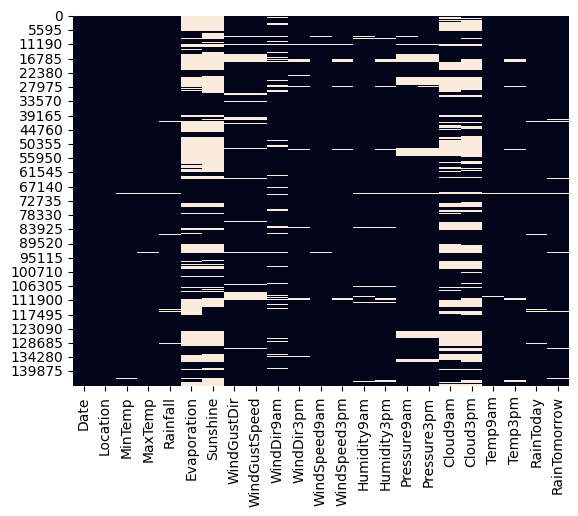

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

#visualiser les valeurs nulles
print("visualiser les valeurs nulles")
sns.heatmap(df_weather_brut.isnull(), cbar=False)
plt.show()

CONCLUSION : les cols les plus affectées sont
"Evaporation"
"Sunshine"
"Cloud9am"
"Cloud3pm"

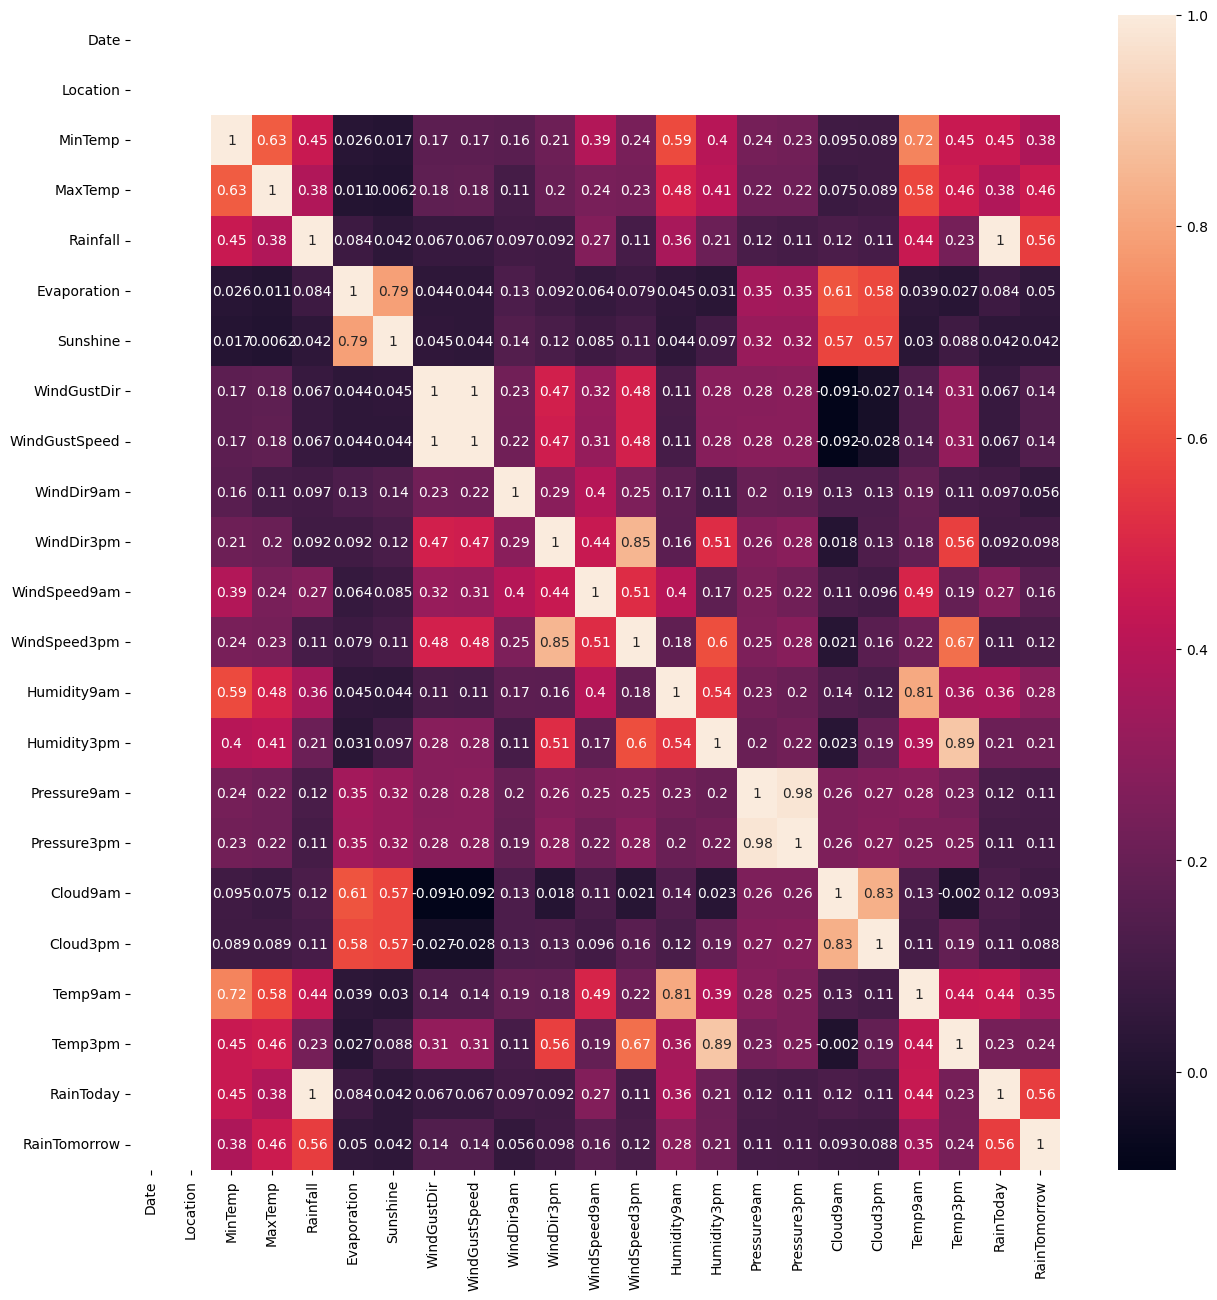

In [9]:
fig, axs = plt.subplots(figsize=(15, 15))
df_nan_col = df_weather_brut.isna().corr()
sns.heatmap(df_nan_col, annot=True, ax=axs)
plt.show()

La heatmap présence montre une assez forte corrélation entre "Evaporation"vs "Sunshine" pareil pour "Cloud9am" vs "Cloud3pm"
on peut donc conclure un MAR, Missing At Random(le manque d'une valeur est lié à une autre) on va utiliser d'autre variables pour les imputer par la méthode IterativeImputer


## ANALYSE DE LA DISTRIBUTION

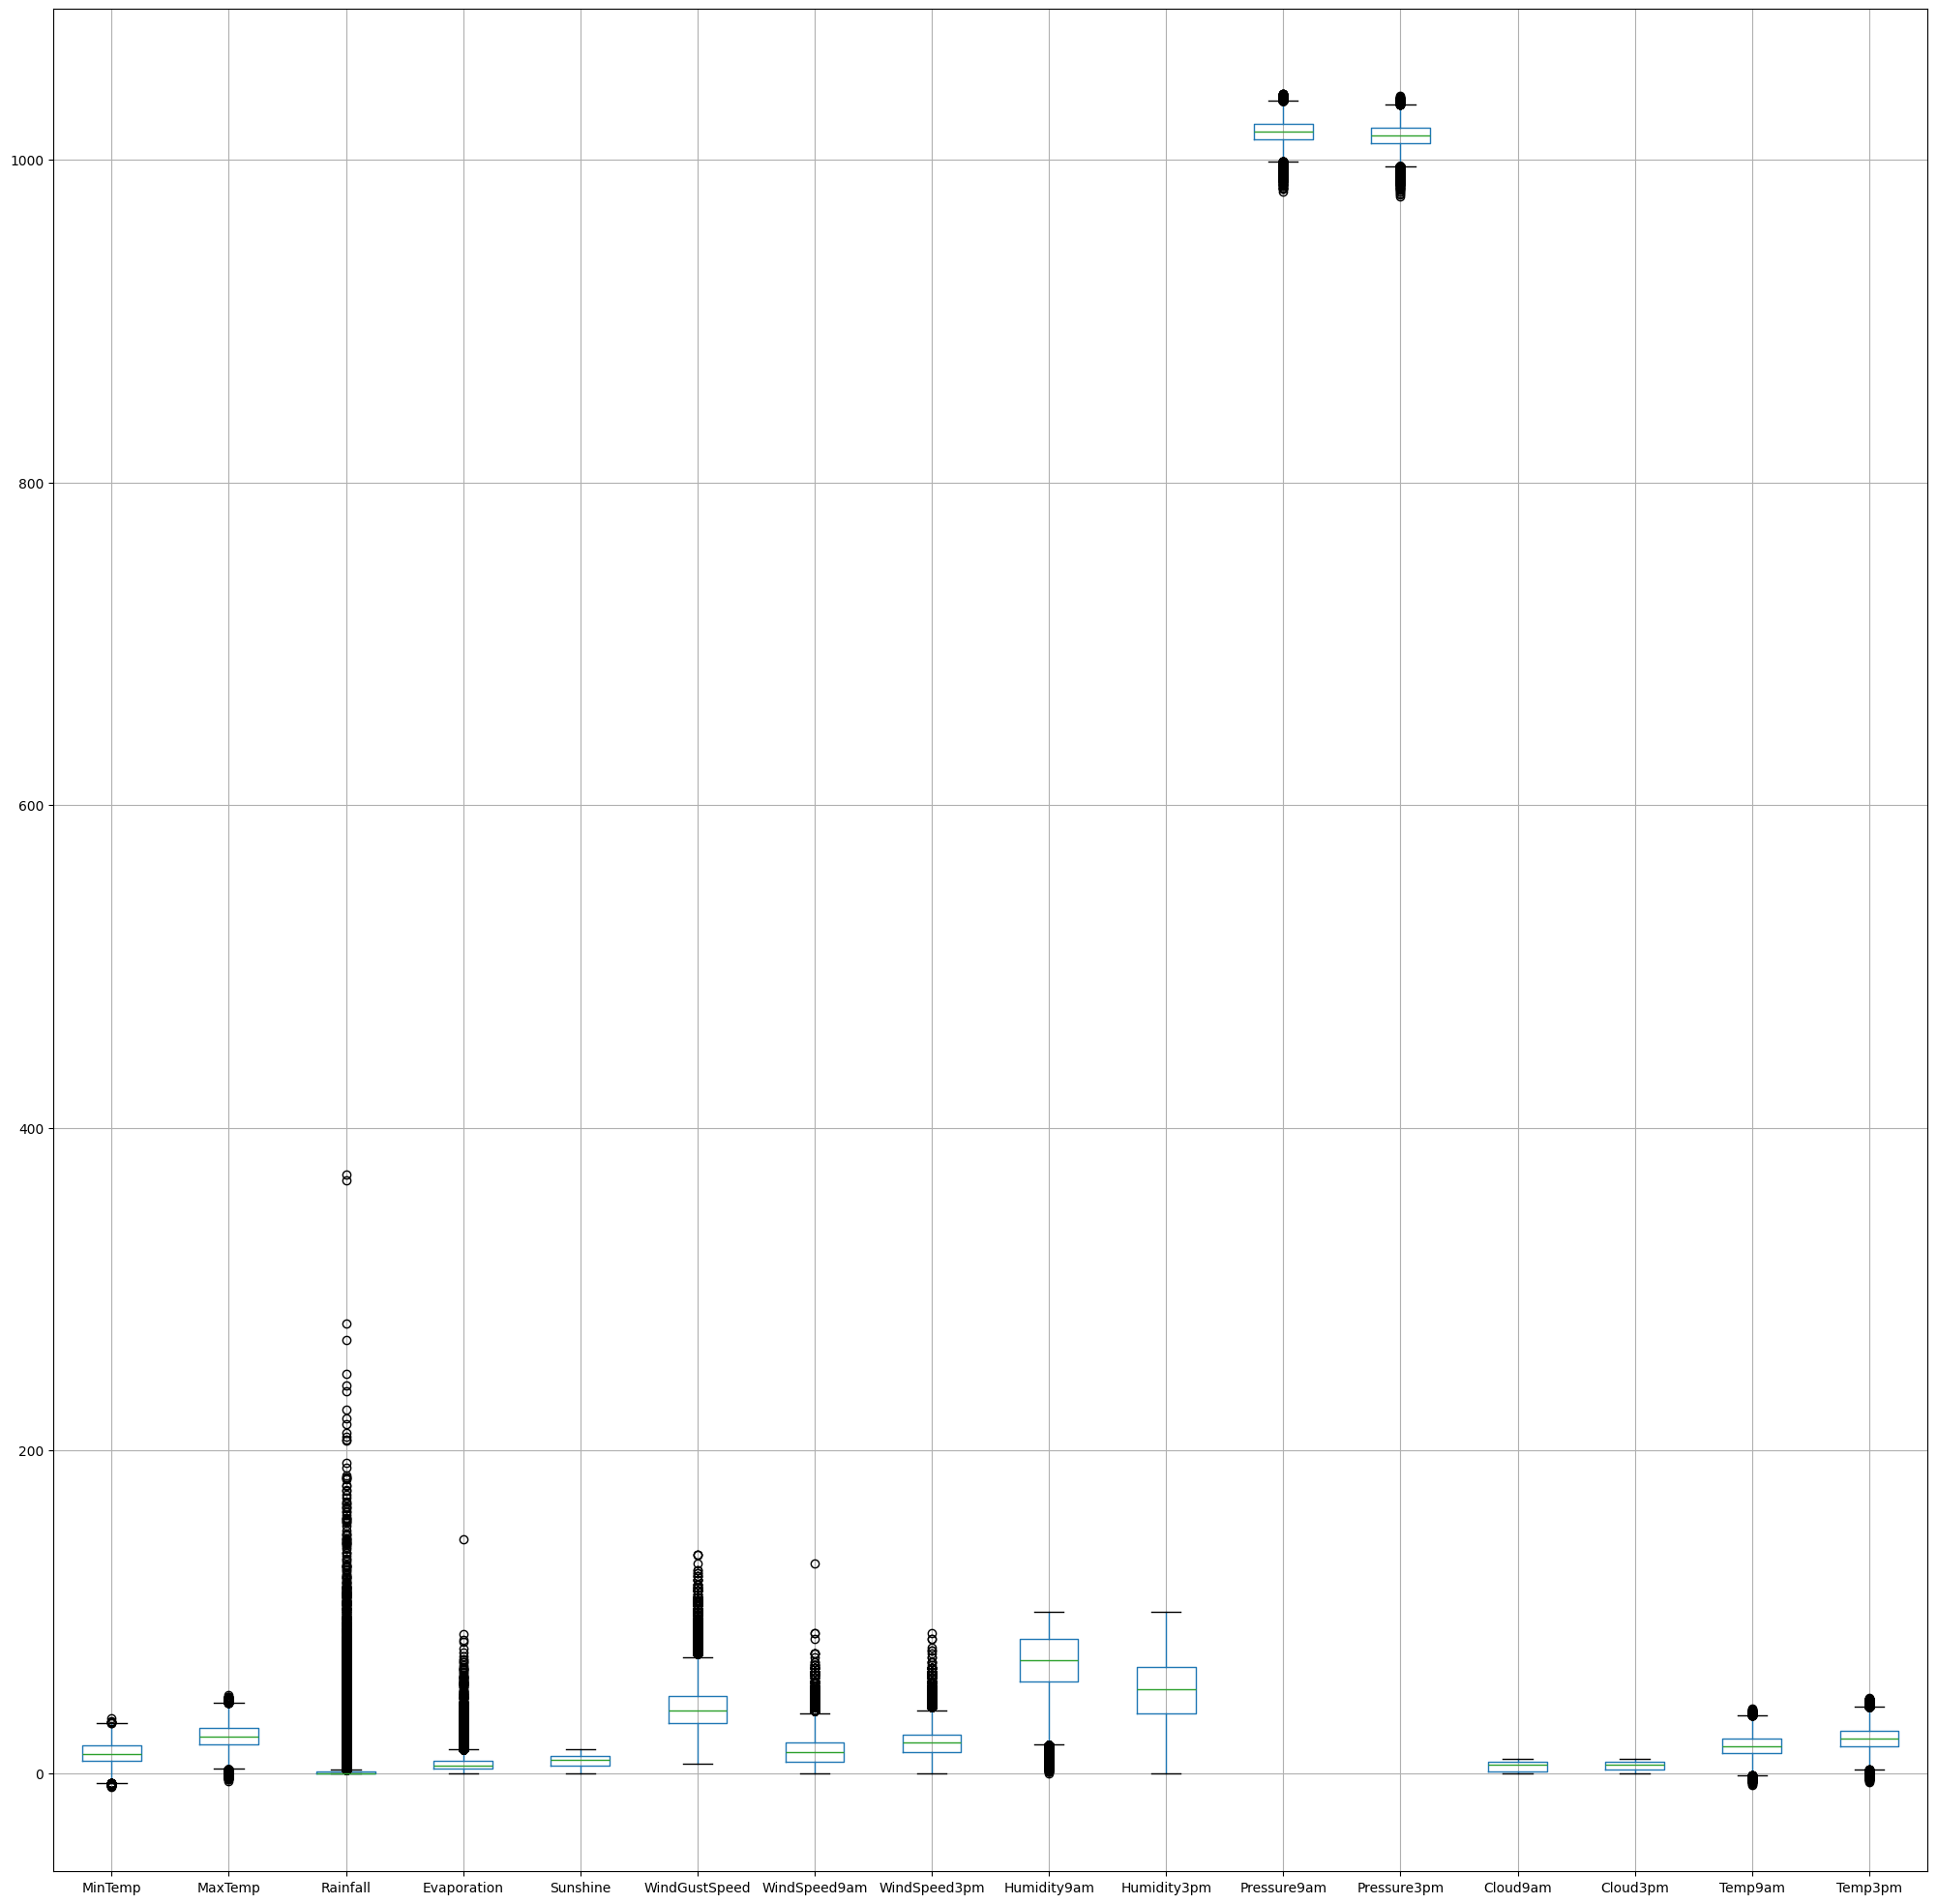

In [10]:
df_numerique = df_weather_brut.select_dtypes(include=['number'])
df_numerique.boxplot(figsize=(25, 25))
plt.show()

On constate que les variables "Rainfall" et "Evaporation" sont très asymétrique

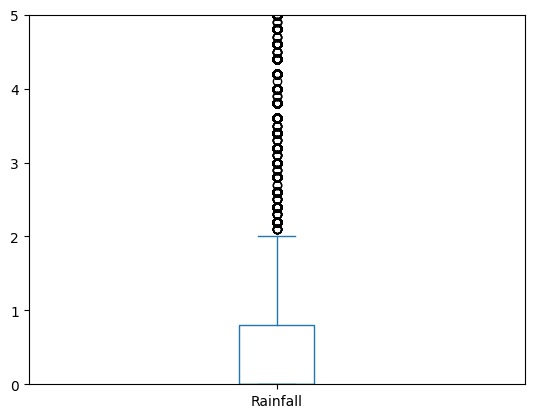

In [11]:
df_numerique['Rainfall'].plot.box()
plt.ylim(0, 5)
plt.show()


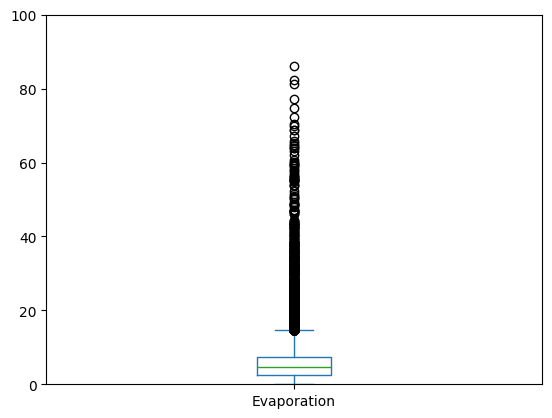

In [12]:
df_numerique['Evaporation'].plot.box()
plt.ylim(0, 100)
plt.show()

In [13]:
# Calcul du Skewness (asymétrie) pour toutes les colonnes
skewness = df_numerique.skew().sort_values(ascending=False)
print("Colonnes les plus asymétriques :\n", skewness)

Colonnes les plus asymétriques :
 Rainfall         9.836225
Evaporation      3.761286
WindGustSpeed    0.874879
WindSpeed9am     0.777630
WindSpeed3pm     0.628215
Temp3pm          0.237960
MaxTemp          0.220839
Temp9am          0.088540
Humidity3pm      0.033614
MinTemp          0.021188
Pressure3pm     -0.045621
Pressure9am     -0.095524
Cloud3pm        -0.226384
Cloud9am        -0.229082
Humidity9am     -0.483969
Sunshine        -0.496480
dtype: float64


Le calcul du skewness le confirme
conclusion : appliquer la transformation logarithmique + RobusScaler

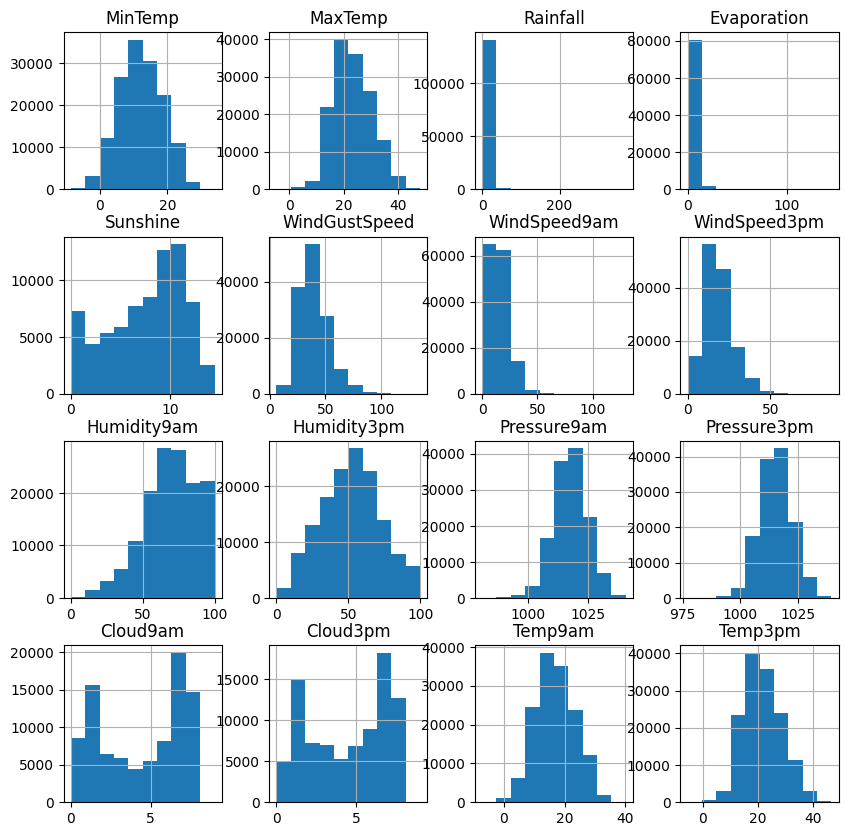

In [14]:
df_numerique.hist(figsize=(10, 10))
plt.show()

L'analyse de l'histogramme global montre une assez bonnne distribution pour les autres variables

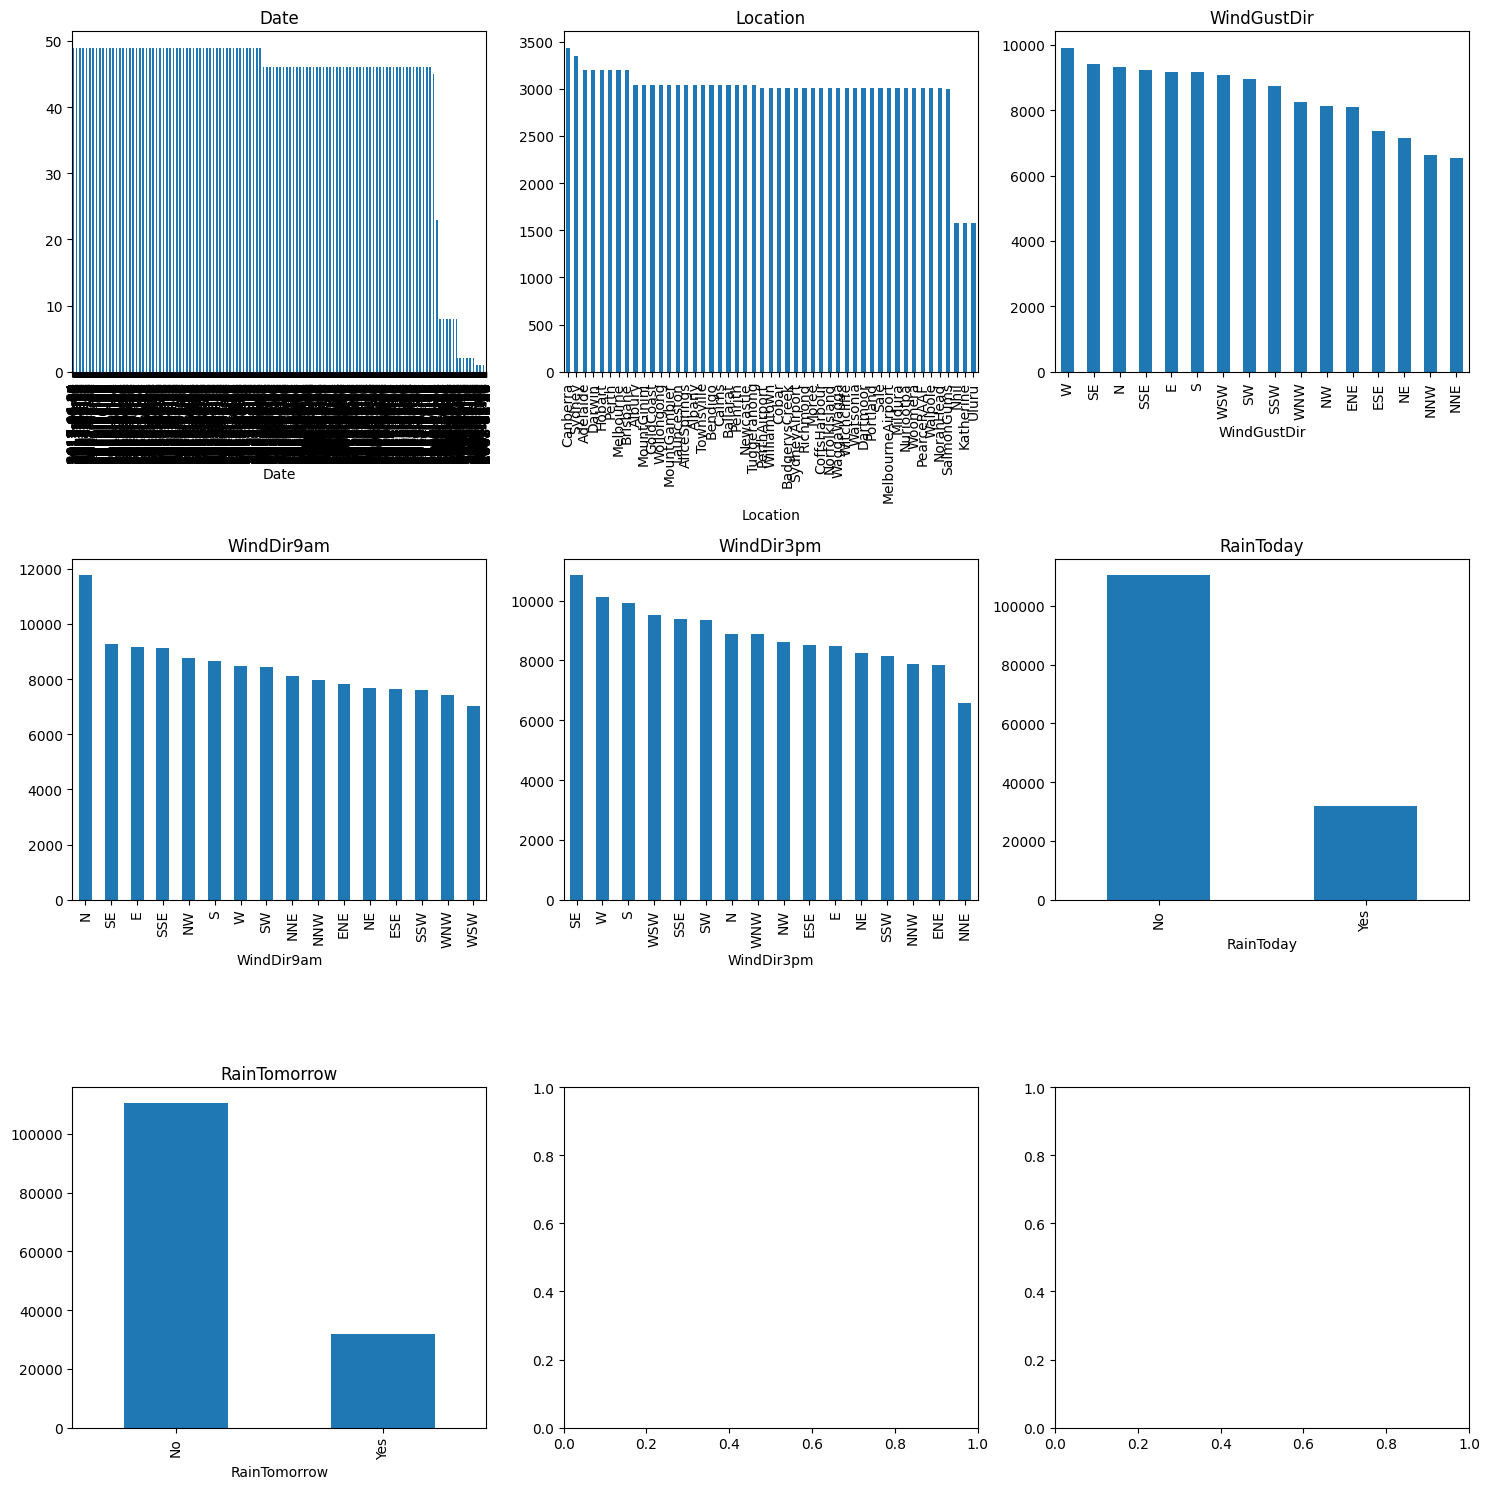

In [15]:
df_categoriel = df_weather_brut.select_dtypes(exclude=['number']) #juste les colonnes categorielle

n_col = 3                                                                  #nb colonne
n_row =  (len(df_categoriel.columns) + n_col - 1) // n_col                 #nb ligne

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 15))                    #figure

for i, col in enumerate(df_categoriel.columns):
  row_idx = i // n_col
  col_idx = i % n_col
  plt.subplot(n_row, n_col, i+1)
  df_categoriel[col].value_counts().plot(kind='bar', ax=axs[row_idx, col_idx])
  axs[row_idx, col_idx].set_title(col)

plt.tight_layout()
plt.show()

Sur l'ensemble des variables catégorielles il y'a pas de variable qui domine. Elle sont bonne au niveau de la distribution.
Néanmoins on peut observer une disparité sur RainToday

# En conclusion les prétraitements à faire

1. la colonne Date est de type object pas idéale : nous allons la transformer en type date et ensuite extraite jour - mois - année, et les rendre cyclique

2. la colonne Location chaine de carractère : il faut la rendre numérique

3. WindGustDir, WindDir9am, WindDir3pm  seront transformé en categorie numérique

4. RainToday et RainTomorrow(la cible) tranformer en
ON va supprimer les NaN sur RainTomorrow

5. imputation : toutes les colonnes sauf date et Location

toutes les colonnes seront imputer

6. les colonne qui representes les températures peuvent être négatives : centré reduire

7. Asymétrie ( seulemenet pour les modèles linéaires donc  à faire dans les classes)
on va appliquer la transformation logarithmique + RobusScaler sur Rainfall et Evaporation

8. Création de 3 colonnes
    Tem_diff = amplitude thermiques
    Pressure_diff = Chutte de pression
    Humidity_diff = evolution de l'humidity

In [ ]:
# Debut des traitements
import numpy as np

#1.
df_weather_brut['Date'] = pd.to_datetime(df_weather_brut['Date']) #tranformer en type date

df_weather_brut['Day'] = df_weather_brut['Date'].dt.day  # jour
df_weather_brut['Month'] = df_weather_brut['Date'].dt.month # mois
df_weather_brut['Year'] = df_weather_brut['Date'].dt.year # année

#cyclique
df_weather_brut["Month"] = np.sin(2*np.pi * df_weather_brut["Month"]/12)
df_weather_brut["Day"] = np.sin(2*np.pi * df_weather_brut["Day"]/12)
df_weather_brut["Year"] = np.sin(2*np.pi * df_weather_brut["Day"]/12)

df_weather_brut.drop('Date', axis=1, inplace=True) # supprimer la colonne initiale

df_test_date = df_weather_brut[['Day', 'Month', 'Year']]
df_test_date



,Day,Month,Year
0,5.000000e-01,-2.449294e-16,0.866025
1,8.660254e-01,-2.449294e-16,0.866025
2,1.000000e+00,-2.449294e-16,0.866025
3,8.660254e-01,-2.449294e-16,0.866025
4,5.000000e-01,-2.449294e-16,0.866025
...,...,...,...
145455,-1.000000e+00,1.224647e-16,0.500000
145456,-8.660254e-01,1.224647e-16,0.500000
145457,-5.000000e-01,1.224647e-16,0.500000
145458,-4.898587e-16,1.224647e-16,0.500000


In [17]:
#2. 3. Location et WindGustDir, WindDir9am, WindDir3pm
print(f"Nombre de valeur distincte Location {df_weather_brut['Location'].nunique()}")
print(f"Nombre de valeur distincte WindGustDir {df_weather_brut['WindGustDir'].nunique()}")
print(f"Nombre de valeur distincte WindDir9am {df_weather_brut['WindDir9am'].nunique()}")
print(f"Nombre de valeur distincte WindDir3pm {df_weather_brut['WindDir3pm'].nunique()}")


Nombre de valeur distincte Location 49
Nombre de valeur distincte WindGustDir 16
Nombre de valeur distincte WindDir9am 16
Nombre de valeur distincte WindDir3pm 16


In [18]:

" on va opter pour un encodage label encoder"
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()  #encoder

df_weather_brut['Location'] = label_encoder.fit_transform(df_weather_brut['Location']) #transformer
print(f" Resultat Location: \n {df_weather_brut['Location']}")

df_weather_brut['WindGustDir'] = label_encoder.fit_transform(df_weather_brut['WindGustDir'])
print(f" Resultat WindGustDir: \n {df_weather_brut['WindGustDir']}")

df_weather_brut['WindDir9am'] = label_encoder.fit_transform(df_weather_brut['WindDir9am'])
print(f" Resultat WindDir9am: \n {df_weather_brut['WindDir9am']}")

df_weather_brut['WindDir3pm'] = label_encoder.fit_transform(df_weather_brut['WindDir3pm'])
print(f" Resultat WindDir3pm: \n {df_weather_brut['WindDir3pm']}")

 Resultat Location: 
 0          2
1          2
2          2
3          2
4          2
          ..
145455    41
145456    41
145457    41
145458    41
145459    41
Name: Location, Length: 145460, dtype: int64
 Resultat WindGustDir: 
 0         13
1         14
2         15
3          4
4         13
          ..
145455     0
145456     6
145457     3
145458     9
145459    16
Name: WindGustDir, Length: 145460, dtype: int64
 Resultat WindDir9am: 
 0         13
1          6
2         13
3          9
4          1
          ..
145455     9
145456     9
145457     9
145458    10
145459     2
Name: WindDir9am, Length: 145460, dtype: int64
 Resultat WindDir3pm: 
 0         14
1         15
2         15
3          0
4          7
          ..
145455     1
145456     3
145457    14
145458     3
145459     2
Name: WindDir3pm, Length: 145460, dtype: int64


In [ ]:
#4. RainToday et RainTomorrow(la cible) tranformer en booléen 5. imputation : toutes les colonnes sauf date et Location toutes les colonnes seront imputer

##supprimer NaN sur cible
df_weather_brut.dropna(subset=['RainTomorrow'], inplace=True)

#mapping
mapping = {'Yes': 1, 'No': 0}
df_weather_brut['RainToday'] = df_weather_brut['RainToday'].map(mapping)
df_weather_brut['RainTomorrow'] = df_weather_brut['RainTomorrow'].map(mapping)

#imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42, min_value=0)
df_without_cible = df_weather_brut.drop('RainTomorrow', axis=1)
df_weather_brut[df_without_cible.columns] = imputer.fit_transform(df_without_cible)

df_weather_brut['RainToday'] = df_weather_brut['RainToday'].astype(int)

df_weather_brut[['RainTomorrow', 'RainToday', 'WindGustDir']]

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,RainTomorrow,RainToday,WindGustDir
0,0,0,13.0
1,0,0,14.0
2,0,0,15.0
3,0,0,4.0
4,0,0,13.0
...,...,...,...
145454,0,0,0.0
145455,0,0,0.0
145456,0,0,6.0
145457,0,0,3.0


In [20]:
#8.
df_weather_brut["Temp_diff"] = df_weather_brut["Temp9am"] - df_weather_brut["Temp3pm"]
df_weather_brut["Pressure_diff"] = df_weather_brut["Pressure9am"] - df_weather_brut["Pressure3pm"]
df_weather_brut["Humidity_diff"] = df_weather_brut["Humidity9am"] - df_weather_brut["Humidity3pm"]


In [21]:
#charger le df final
from operator import index
df_weather_brut.to_csv('/content/drive/MyDrive/Documents/GIA3/IAA/data/df_weather_nettoye.csv', index=False)

In [22]:
#analyse pour savoir s'il y'a une serie temporelle
tableau = pd.crosstab(df_weather_brut['RainToday'], df_weather_brut['RainTomorrow'], normalize="index") *100
print("Probabilité de pluie demain en fonction d'aujourd'hui :\n")
print(tableau.round(1))

Probabilité de pluie demain en fonction d'aujourd'hui :

RainTomorrow     0     1
RainToday               
0             84.4  15.6
1             53.6  46.4


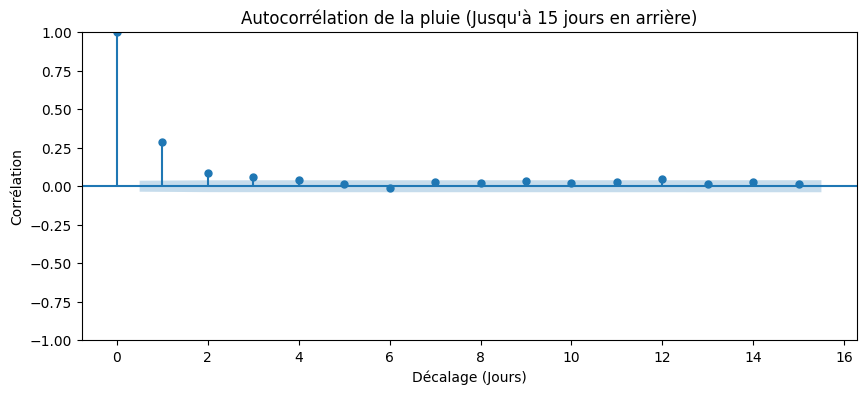

In [23]:
#analyse de l'autocorrélation
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

#on prend une ville précise
df_ville =  df_weather_brut[df_weather_brut['Location'] == df_weather_brut["Location"].iloc[0]].copy()

#on trace la corrélation sur les 15 dernier jours
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df_ville['RainTomorrow'].dropna(), lags=15, ax=ax)
plt.title("Autocorrélation de la pluie (Jusqu'à 15 jours en arrière)")
plt.xlabel("Décalage (Jours)")
plt.ylabel("Corrélation")
plt.show()